# Problem Setup (Damped Harmonic Oscillator)

**PDE:**
$$m \frac{d^2 x}{dt^2} + \mu \frac{dx}{dt} + kx = 0,$$

dengan kondisi batas
$$x(0)=1, \frac{dx}{dt}=0$$

Kita akan fokus untuk mennyelesaikan under-damped ketika:
$$ \delta < \omega_0 $$, dengan $$\delta = \frac{\mu}{2m},\omega_0=\sqrt{\frac{k}{m}}$$

Dengan eksak solusi:
$$x(t) = e^{\delta t}(2A cos(\phi + \omega t)) $$ dengan $$\omega = \sqrt{\omega_{0}^2 - \delta^2}$$

**Loss Residual:**
Andaikan $y_{nn}$ merupakan fungsi neural networks. Sehingga residualnya


Karena memakai hard constraint dengan $p(x)=x(1-x)$,maka kita tidak memerlukan loss dari bc. Sehingga total dari loss:


In [1]:
import torch
import torch.autograd as autograd   # computation graph
from torch import Tensor # tensor node in the computation graph
import torch.nn as nn # neural network from torch
import torch.optim as optim # optimizers

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
import time
import pandas as pd
import scipy.io

torch.set_default_dtype(torch.float)

torch.manual_seed(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
def oscillator(d, w0, x):
  """Defines the analytical solution to the 1D underdamped harmonic oscillator problem.
    Equations taken from: https://beltoforion.de/en/harmonic_oscillator/"""
  assert d < w0
  w = np.sqrt(w0**2 - d**2)
  phi = np.arctan(-d/w)
  A = 1/(2*np.cos(phi))
  cos = torch.cos(phi + w*x)
  sin = torch.sin(phi + w*x)
  exp = torch.exp(-d*x)
  y = exp*2*A*cos
  return y

## NEURAL NETWORKS

In [3]:
# MLP model
class PINN(nn.Module):
  """ set hidden layer"""
  def __init__(self, n_hidden):
    super(PINN, self).__init__()

    # 3 hidden layer
    self.net = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.Tanh(),
        nn.Linear(n_hidden, n_hidden),
        nn.Tanh(),
        nn.Linear(n_hidden, n_hidden),
        nn.Tanh(),
        nn.Linear(n_hidden, 1)
        )
  def forward(self,x):
    """
    Forward pass : input shape (batch_size,1) -> output shape
    """
    nn_out = self.net(x)

    return nn_out

model = PINN(n_hidden=25).to(device)
# Perkecil bobot layer output agar u awal mendekati 0
with torch.no_grad():
    model.net[-1].weight.mul_(0.01)
    model.net[-1].bias.mul_(0.01)

# Automatic Differentiation
def derivative(y,x):
  """
  Compute the derivative of y with respect to x
  """
  return torch.autograd.grad(
      y,x,
      grad_outputs=torch.ones_like(y),
      retain_graph=True,
      create_graph=True
      )[0]

## LOSS RESIDUAL

In [4]:
def data_loss(model, x_data, y_data):
  """
  Compute the loss dari data training (titik sampel solusi eksak)
  """
  yh = model(x_data)
  return torch.mean((yh - y_data)**2)


def physics_loss(model,x,mu, k):
  """
  Compute the loss residual of the PDE
  F = x_tt + mu*x_t + k*x
  """
  u = model(x)
  u_x = derivative(u, x)
  u_xx = derivative(u_x, x)
  f = u_xx + mu * u_x + k*u
  loss_pde = torch.mean(f**2)
  return loss_pde

## SETTING PROBLEM
> First, we generate some training data from domain of the true analytical solusion

Untuk masalah ini, kita menggunakan $\delta=2,\omega_0=20$ dan coba mencari dengan domain $x \in [0,1]$

x shape: torch.Size([500, 1])
y shape: torch.Size([500, 1])
x_data shape: torch.Size([10, 1])
y_data shape: torch.Size([10, 1])


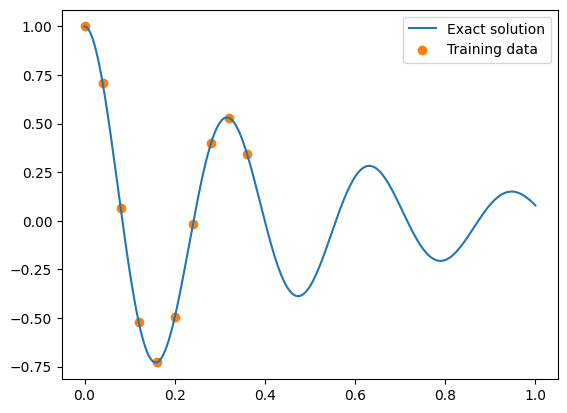

In [5]:
d = 2
w0 = 20

# analytical solution
x = torch.linspace(0,1,500).view(-1,1)
y = oscillator(d,w0,x).view(-1,1)
print("x shape:", x.shape)
print("y shape:", y.shape)
# slice out a small number of ppoint from LHS of the domain
x_data = x[0:200:20]
y_data = y[0:200:20]
print("x_data shape:", x_data.shape)
print("y_data shape:", y_data.shape)

x_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)
# print(x_physics)
# titik t=0 untuk initial condition loss (butuh grad terhadap x)
x0 = torch.zeros(1,1).requires_grad_(True)

plt.figure()
plt.plot(x,y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange",label="Training data")
plt.legend()
plt.show()

## ADAM

In [6]:
mu = 2*d
k = w0**2

# optimizer Adam
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

lambda_physics = 1e-4  # bobot physics loss (data loss dari solusi eksak)

# Training dengan log loss di setiap epoch
n_epochs = 20000
loss_log = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss = data_loss(model, x_data, y_data) + lambda_physics*physics_loss(model, x_physics, mu, k)
    loss.backward()
    optimizer.step()
    loss_log.append(loss.item())

    if (epoch+1) % 1000 == 0:
        print(f"Iter {epoch+1:6d} | loss: {loss_log[-1]:.6e}")

loss_history = loss_log


Iter   1000 | loss: 2.992141e-01
Iter   2000 | loss: 4.525527e-02
Iter   3000 | loss: 3.021053e-02
Iter   4000 | loss: 1.607101e-02
Iter   5000 | loss: 1.418319e-02
Iter   6000 | loss: 8.651396e-03
Iter   7000 | loss: 6.666277e-03
Iter   8000 | loss: 5.860570e-03
Iter   9000 | loss: 2.393903e-03
Iter  10000 | loss: 1.670127e-04
Iter  11000 | loss: 4.305202e-05
Iter  12000 | loss: 2.342905e-05
Iter  13000 | loss: 1.013006e-05
Iter  14000 | loss: 3.045603e-06
Iter  15000 | loss: 3.975717e-06
Iter  16000 | loss: 6.632657e-07
Iter  17000 | loss: 5.788473e-07
Iter  18000 | loss: 3.454385e-07
Iter  19000 | loss: 2.737051e-07
Iter  20000 | loss: 1.006249e-06


## L-BFGS

In [7]:
# koefisien PDE damped oscillator, m*x_tt + mu*x_t + k*x = 0 (asumsi m=1)
mu = 2*d
k = w0**2

# jacobian for l-bfgs
optimizer = torch.optim.LBFGS(
    model.parameters(),
    max_iter=10000,
    history_size=100,
    tolerance_grad=1e-6,
    tolerance_change=1e-09,
    line_search_fn="strong_wolfe"
)

lambda_physics = 1e-4  # physics loss (data loss dari solusi eksak)


# Training dengan log loss di setiap evaluasi closure
loss_log = []

def closure():
    optimizer.zero_grad()
    # loss = physics_loss(model, x_physics, mu, k) -> hard constraint
    loss = data_loss(model, x_data, y_data) + lambda_physics*physics_loss(model, x_physics, mu, k)
    loss.backward()
    loss_log.append(loss.item())
    return loss

loss_history = []
for epoch in range(1):
    loss = optimizer.step(closure)
    loss_history.append(loss.item())

# Tampilkan setiap iterasi loss
for i, l in enumerate(loss_log):
    print(f"Iter {i+1:4d} | loss: {l:.6e}")

In [8]:
# loss SETELAH training selesai (parameter sudah ter-update)
final_loss_actual = data_loss(model, x_data, y_data) + lambda_physics*physics_loss(model, x_physics, mu, k)
print(f"Actual final loss: {final_loss_actual.item():.6e}")

Actual final loss: 1.380848e-06


In [9]:
with torch.no_grad():
  u_pred = model(x)

u_analytic = oscillator(d, w0, x)

# Metrik Rel. L2
l2_error = torch.linalg.norm(u_pred - u_analytic) / torch.linalg.norm(u_analytic)
# Metrik MSE
MSE = torch.mean((u_pred - u_analytic)**2)

print(f"MSE: {MSE.item():.6e}")
print(f"L2 relative error: {l2_error.item():.6e}")


MSE: 3.140440e-06
L2 relative error: 4.940473e-03


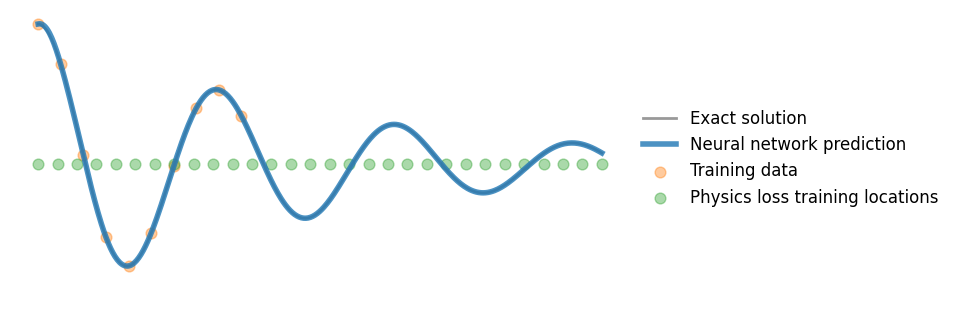

In [10]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
  "Pretty plot training results"
  plt.figure(figsize=(8,4))
  plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
  plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
  plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
  if xp is not None:
    plt.scatter(xp, -0*torch.ones_like(xp), s=60, color="tab:green", alpha=0.4,
                label='Physics loss training locations')
  l = plt.legend(loc=(1.01, 0.34), frameon=False, fontsize="large")
  plt.setp(l.get_texts(), color="k")
  plt.xlim(-0.05, 1.05)
  plt.ylim(-1.1, 1.1)
  plt.axis("off")

plot_result(x, y, x_data, y_data, u_pred, x_physics.detach())
plt.show()


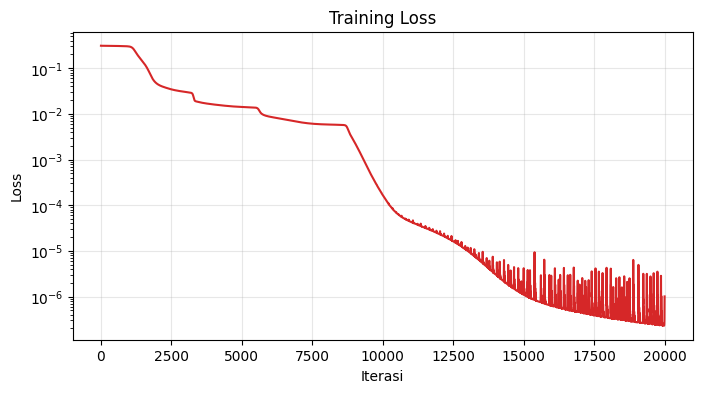

In [11]:
plt.figure(figsize=(8,4))
plt.plot(loss_log, color="tab:red", linewidth=1.5)
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.show()